<a href="https://colab.research.google.com/github/maheshkumar30/DataScience/blob/main/Global_Commodity_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew, shapiro, ttest_ind

df = pd.read_csv("commodity_prices.csv")

In [27]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       756 non-null    int64  
 1   date             756 non-null    object 
 2   oil_brent        756 non-null    float64
 3   oil_dubai        756 non-null    float64
 4   coffee_arabica   756 non-null    float64
 5   coffee_robustas  756 non-null    float64
 6   tea_columbo      756 non-null    float64
 7   tea_kolkata      756 non-null    float64
 8   tea_mombasa      756 non-null    float64
 9   sugar_eu         756 non-null    float64
 10  sugar_us         756 non-null    float64
 11  sugar_world      756 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 71.0+ KB


,Unnamed: 0,oil_brent,oil_dubai,coffee_arabica,coffee_robustas,tea_columbo,tea_kolkata,tea_mombasa,sugar_eu,sugar_us,sugar_world
count,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000,756.000000
mean,378.500000,32.724944,31.238130,2.576555,1.727478,1.777962,1.870308,1.671222,0.405158,0.432462,0.240263
std,218.382692,31.885368,30.936611,1.342454,0.940748,1.008679,0.697867,0.615357,0.187741,0.188589,0.151947
min,1.000000,1.210000,1.210000,0.777600,0.487210,0.434198,0.664799,0.719600,0.112215,0.116845,0.028700
25%,189.750000,10.564999,10.452500,1.351625,0.923053,0.892501,1.297369,1.136800,0.298120,0.297624,0.139705
50%,378.500000,20.489130,18.550000,2.697794,1.632172,1.504001,1.850612,1.598257,0.402343,0.471119,0.215285
75%,567.250000,47.157500,45.576023,3.312950,2.282200,2.515204,2.376899,2.083830,0.569519,0.512188,0.309325
max,756.000000,133.873043,131.224783,7.003600,6.883547,4.490000,4.073011,3.392500,0.783171,1.263247,1.237700


In [28]:
df['date'] = pd.to_datetime(df['date'])

In [29]:
df.isnull().sum()

,0
Unnamed: 0,0
date,0
oil_brent,0
oil_dubai,0
coffee_arabica,0
coffee_robustas,0
tea_columbo,0
tea_kolkata,0
tea_mombasa,0
sugar_eu,0


In [30]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_4247/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


**1. Maximum price of Robusta coffee**

In [31]:
max_robusta = df['coffee_robustas'].max()

print("Maximum Robusta Coffee Price:", max_robusta)

Maximum Robusta Coffee Price: 6.883547


**2. 75th percentile of EU sugar prices**

In [32]:
percentile_75 = df['sugar_eu'].quantile(0.75)

print("75th Percentile:", percentile_75)

75th Percentile: 0.56951937998


**3. Skewness of Arabica coffee price**

In [33]:
arabica_skew = skew(df['coffee_arabica'].dropna())

print("Skewness:", arabica_skew)

Skewness: 0.5892256240650386


**4. Is Sugar_US normally distributed?**

In [34]:
stat, p = shapiro(df['sugar_us'].dropna())

print("P-value:", p)

P-value: 4.46988728891317e-19


**5. Dubai oil exceeds Brent oil by > $10**

In [35]:
count = (df['oil_dubai'] - df['oil_brent'] > 10).sum()

print("Count:", count)

Count: 0


**6. Overall price trend for each commodity**

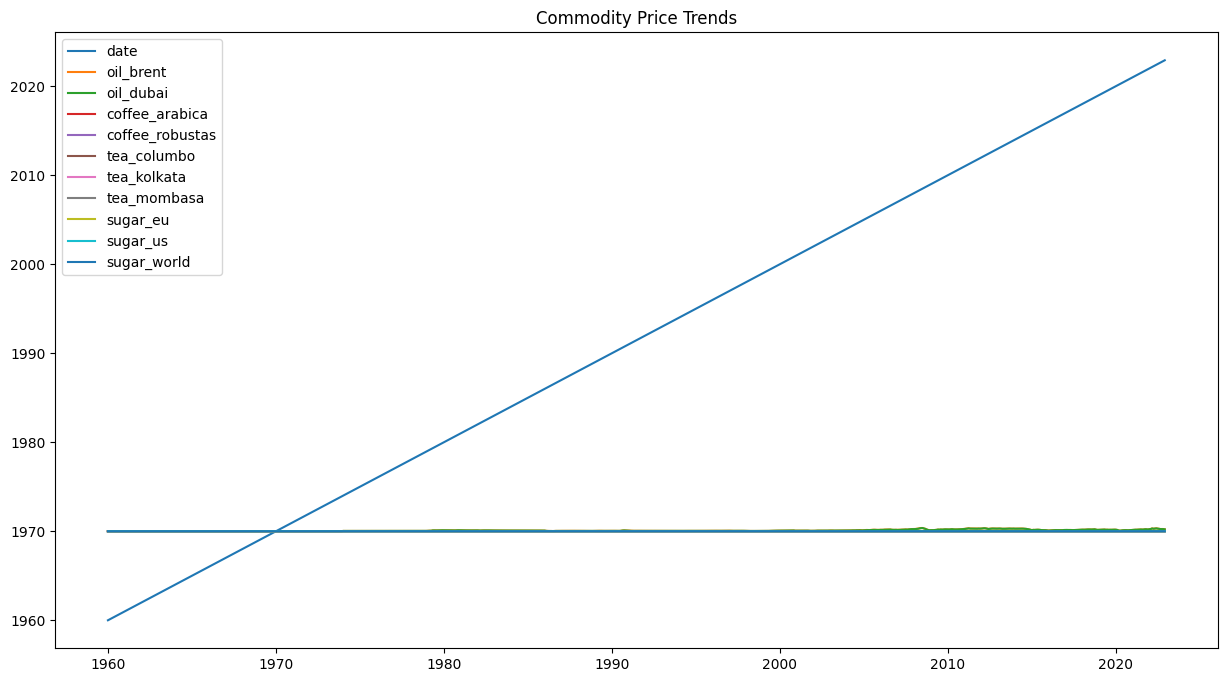

In [36]:
commodities = df.columns[1:]

plt.figure(figsize=(15,8))

for col in commodities:
    plt.plot(df['date'], df[col], label=col)

plt.legend()
plt.title("Commodity Price Trends")
plt.show()

**7. Highest price fluctuations**

In [37]:
fluctuations = df.select_dtypes(include=['number']).std()

print(fluctuations.sort_values(ascending=False))

Unnamed: 0         218.382692
oil_brent           31.885368
oil_dubai           30.936611
coffee_arabica       1.342454
tea_columbo          1.008679
coffee_robustas      0.940748
tea_kolkata          0.697867
tea_mombasa          0.615357
sugar_us             0.188589
sugar_eu             0.187741
sugar_world          0.151947
dtype: float64


**8. Brent oil quarterly trend (last 5 years)**

In [38]:
last_5_years = df[df['date'] >= df['date'].max() - pd.DateOffset(years=5)]

/tmp/ipykernel_4247/3506343646.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly = last_5_years.resample('Q', on='date')['oil_brent'].mean()


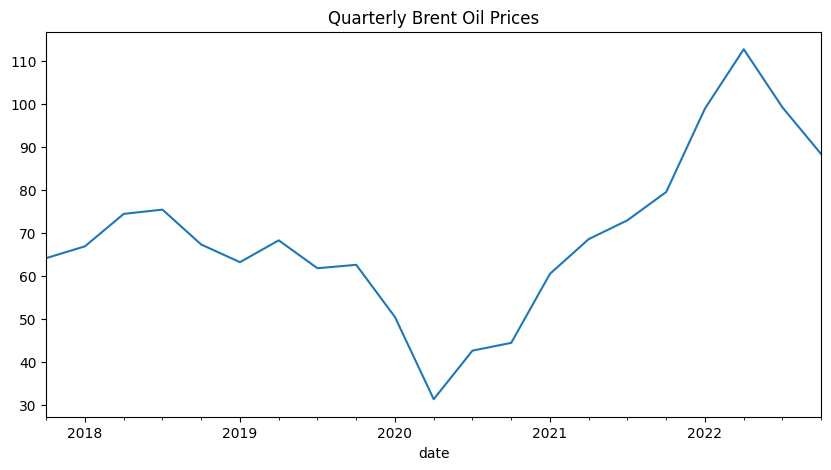

In [39]:
quarterly = last_5_years.resample('Q', on='date')['oil_brent'].mean()

quarterly.plot(figsize=(10,5))
plt.title("Quarterly Brent Oil Prices")
plt.show()

**9. Correlation between Sugar prices**

In [40]:
corr = df[['sugar_world', 'sugar_eu', 'sugar_us']].corr()

print(corr)

             sugar_world  sugar_eu  sugar_us
sugar_world     1.000000  0.304783  0.794707
sugar_eu        0.304783  1.000000  0.590955
sugar_us        0.794707  0.590955  1.000000


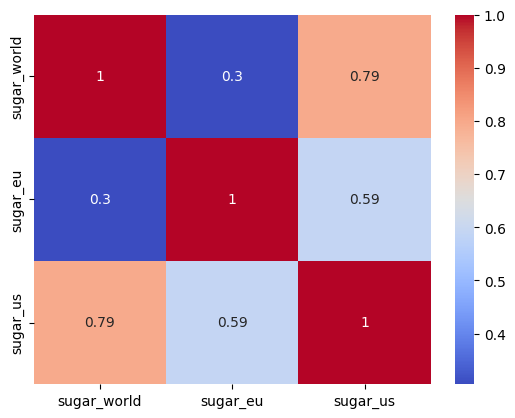

In [41]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**10. Difference between Sugar_EU & Sugar_US distributions**

In [42]:
t_stat, p_val = ttest_ind(df['sugar_eu'].dropna(),
                          df['sugar_us'].dropna())

print("P-value:", p_val)

P-value: 0.004846471007525567


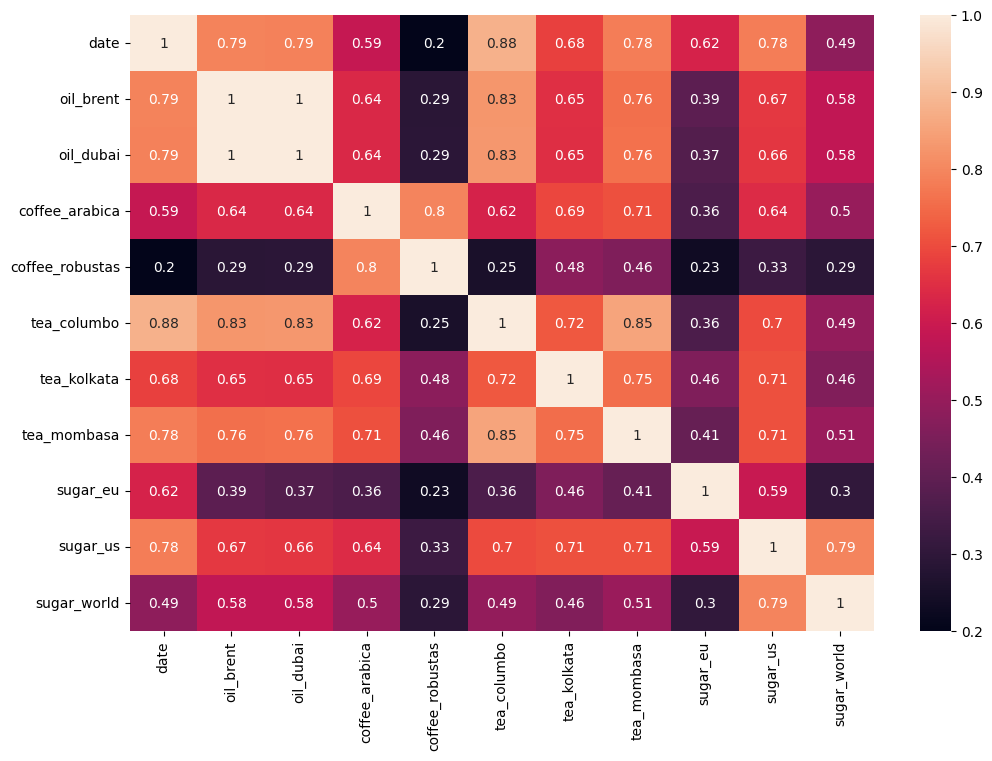

In [43]:
plt.figure(figsize=(12,8))
sns.heatmap(df.iloc[:,1:].corr(), annot=True)
plt.show()

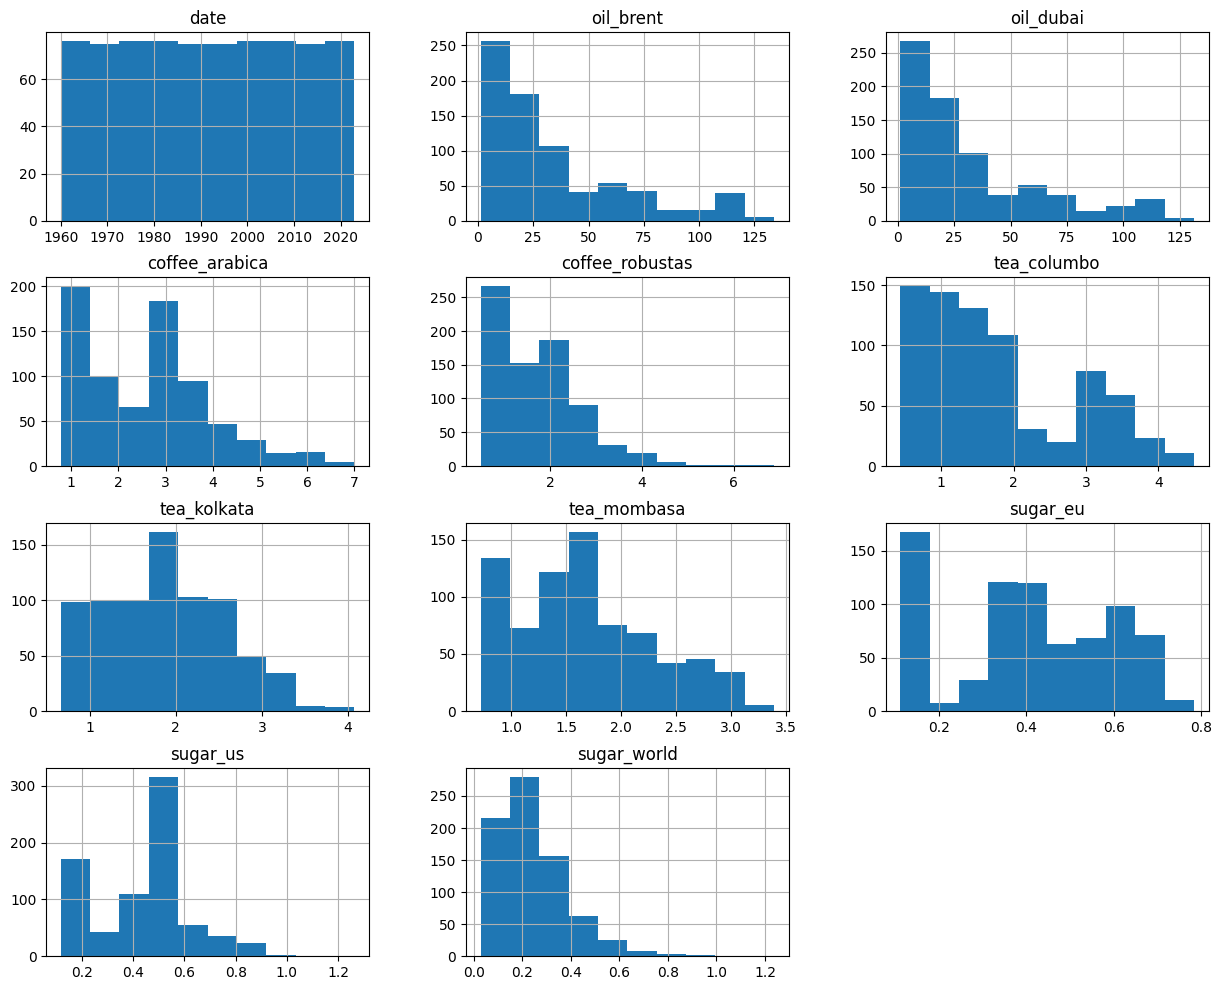

In [44]:
df.iloc[:,1:].hist(figsize=(15,12))
plt.show()